In [20]:
# Chargement du bundle produit par depth_field_V3_2d.ipynb
from pathlib import Path
import numpy as np
from PIL import Image
import open3d as o3d

EXPORT_PATH = Path("C:/Users/mvm/open3d_vision/data/processed") / "depth_field_v3_bundle.npz"
if not EXPORT_PATH.is_file():
    raise FileNotFoundError(
        "Fichier introuvable : exécuter d'abord depth_field_V3_2d.ipynb (cellule d'export).\n"
        f"Attendu : {EXPORT_PATH}"
    )

z = np.load(EXPORT_PATH)
depth_1 = z["depth_1"].astype(np.float64)
rgb1 = z["rgb1"].astype(np.uint8)
image_cropped_1 = Image.fromarray(rgb1)

depth_2_aligned = z["depth_2_remapped"].astype(np.float64)
rgb2 = z["rgb2"].astype(np.uint8)
image_cropped_2 = Image.fromarray(rgb2)

mask_combined = z["mask_combined"].astype(np.uint8)

depth_1_masked = np.where(mask_combined == 255, depth_1, np.nan)
depth_2_masked = np.where(mask_combined == 255, depth_2_aligned, np.nan)

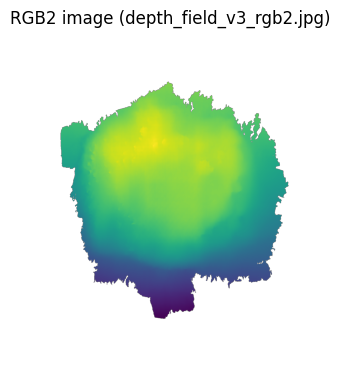

In [21]:
import matplotlib.pyplot as plt
from PIL import Image

# Chargement de la nouvelle image RGB issue de rgb2
rgb2_path = "C:/Users/mvm/open3d_vision/data/processed/depth_field_v3_rgb2.jpg"
rgb2_img = Image.open(rgb2_path)
rgb2_array = np.array(rgb2_img)

plt.figure(figsize=(10, 4))
plt.subplot(1, 1, 1)
plt.imshow(depth_2_masked)
plt.title('RGB2 image (depth_field_v3_rgb2.jpg)')
plt.axis('off')

plt.tight_layout()
plt.show()

In [22]:
def invert_depth_map(depth_map):
    """
    Inverse la carte de profondeur : pixels valides ont valeur max - depth, NaN restent NaN.
    
    Args:
        depth_map (np.ndarray): carte de profondeur à inverser (float, possiblement avec NaN).
    
    Returns:
        np.ndarray: carte de profondeur inversée.
    """
    if not isinstance(depth_map, np.ndarray):
        raise ValueError("depth_map doit être un np.ndarray")
    # Ignore NaN pour trouver le min et max des valeurs valides
    valid = np.isfinite(depth_map)
    if not np.any(valid):
        return depth_map.copy()
    depth_min = np.nanmin(depth_map)
    depth_max = np.nanmax(depth_map)
    # Inversion simple : depth_max + depth_min - depth_map
    inv = np.full(depth_map.shape, np.nan, dtype=depth_map.dtype)
    inv[valid] = depth_max + depth_min - depth_map[valid]
    return inv

# Exemple d'utilisation :
depth_2_inverted = invert_depth_map(depth_2_masked)

In [23]:
new_depth_path = "C:/Users/mvm/open3d_vision/data/processed/depth_1_masked.npy"

Fonctions utilitaires

In [24]:

def _flip_mesh_normals(mesh):
    """Retourne un mesh avec normales inversées (sommets + faces)."""
    m = o3d.geometry.TriangleMesh(mesh)
    # Inversion robuste: inverse les orientations des triangles
    tris = np.asarray(m.triangles)
    if tris.size > 0:
        m.triangles = o3d.utility.Vector3iVector(tris[:, [0, 2, 1]])
    m.compute_triangle_normals()
    m.compute_vertex_normals()
    return m


def _flip_both_mesh_normals(mesh_a, mesh_b):
    """Inversion des normales pour deux meshes."""
    return _flip_mesh_normals(mesh_a), _flip_mesh_normals(mesh_b)
#Fonctions utilitaires : affichage de normales directement dans un mesh 
def _lineset_vertex_normals(mesh, scale=None, max_segments=8000):
    """Segments jaunes = normales aux sommets (sous-échantillonnées)."""
    v = np.asarray(mesh.vertices, dtype=np.float64)
    n = np.asarray(mesh.vertex_normals, dtype=np.float64)
    if v.size == 0 or n.size == 0:
        return None
    step = max(1, int(np.ceil(len(v) / max_segments)))
    v = v[::step]
    n = n[::step]
    nn = np.linalg.norm(n, axis=1, keepdims=True)
    n = np.divide(n, np.maximum(nn, 1e-12))
    if scale is None:
        ext = np.linalg.norm(np.asarray(mesh.get_axis_aligned_bounding_box().get_extent()))
        scale = 0.015 * float(ext)
    ends = v + scale * n
    pts = np.vstack([v, ends])
    m = len(v)
    lines = np.array([[i, i + m] for i in range(m)], dtype=np.int32)
    ls = o3d.geometry.LineSet()
    ls.points = o3d.utility.Vector3dVector(pts)
    ls.lines = o3d.utility.Vector2iVector(lines)
    ls.paint_uniform_color([1.0, 0.85, 0.15])
    return ls


def _prepare_pcd_for_poisson(pcd, voxel_size=0.005, max_points=70000):
    """Downsample + sous-échantillonnage borné pour limiter RAM/CPU."""
    p = pcd.voxel_down_sample(voxel_size)
    pts = np.asarray(p.points)
    if pts.shape[0] > max_points:
        idx = np.linspace(0, pts.shape[0] - 1, max_points, dtype=np.int64)
        p = p.select_by_index(idx.tolist())
    return p


def _poisson_mesh_from_pcd_safe(pcd, voxel_size=0.005, depth=6, density_quantile=0.03):
    """Reconstruction Poisson plus stable (moins agressive)."""
    p = _prepare_pcd_for_poisson(pcd, voxel_size=voxel_size)
    p.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.03, max_nn=30),
        fast_normal_computation=True,
    )
    try:
        p.orient_normals_consistent_tangent_plane(k=10)
    except Exception:
        # Nuages quasi-planaires (ex: pcd_0) peuvent échouer avec QHull.
        p.orient_normals_to_align_with_direction([0.0, 0.0, -1.0])

    # n_threads=1 limite les pics mémoire/CPU sur certaines machines
    mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
        p, depth=depth, n_threads=1
    )

    dens = np.asarray(densities)
    if density_quantile is not None and density_quantile > 0.0:
        thr = np.quantile(dens, density_quantile)
        mesh.remove_vertices_by_mask(dens < thr)

    # Nettoyage topologique sans API tensor (source fréquente de crash natif)
    mesh.remove_duplicated_vertices()
    mesh.remove_duplicated_triangles()
    mesh.remove_degenerate_triangles()
    mesh.remove_non_manifold_edges()
    mesh.remove_unreferenced_vertices()
    mesh.compute_vertex_normals()
    return mesh, p


def _boundary_lines(mesh, max_lines=20000):
    """LineSet des arêtes de bord; tronqué pour visualisation fluide."""
    tris = np.asarray(mesh.triangles)
    edge_count = {}
    for (a, b, c) in tris:
        for u, v in [(a, b), (b, c), (c, a)]:
            e = (min(u, v), max(u, v))
            edge_count[e] = edge_count.get(e, 0) + 1

    boundary_edges = np.array([e for e, c in edge_count.items() if c == 1], dtype=np.int32)
    n_total = int(boundary_edges.shape[0])
    if n_total > max_lines:
        keep = np.linspace(0, n_total - 1, max_lines, dtype=np.int64)
        boundary_edges_vis = boundary_edges[keep]
    else:
        boundary_edges_vis = boundary_edges

    ls = o3d.geometry.LineSet()
    ls.points = mesh.vertices
    if boundary_edges_vis.size > 0:
        ls.lines = o3d.utility.Vector2iVector(boundary_edges_vis)
    else:
        ls.lines = o3d.utility.Vector2iVector(np.empty((0, 2), dtype=np.int32))
    ls.paint_uniform_color([0.0, 1.0, 0.0])
    return ls, n_total


def _voxel_volume_from_pcd(pcd, voxel_size=0.01):
    vg = o3d.geometry.VoxelGrid.create_from_point_cloud(pcd, voxel_size=voxel_size)
    return len(vg.get_voxels()) * (voxel_size ** 3)


def _count_boundary_edges(mesh):
    tris = np.asarray(mesh.triangles)
    edge_count = {}
    for (a, b, c) in tris:
        for u, v in [(a, b), (b, c), (c, a)]:
            e = (min(u, v), max(u, v))
            edge_count[e] = edge_count.get(e, 0) + 1
    return int(sum(1 for c in edge_count.values() if c == 1))


def _seal_mesh_holes_safe(mesh, hole_size=1e6, enable_tensor=False):
    """Tentative robuste de fermeture des trous (tensor fill_holes), avec fallback sûr."""
    n_before = _count_boundary_edges(mesh)
    if n_before == 0:
        return mesh, n_before, n_before, True

    # Désactivé par défaut pour éviter les crash kernel sur gros meshes.
    if not enable_tensor:
        return mesh, n_before, n_before, False

    ok = False
    mesh_out = mesh
    try:
        tmesh = o3d.t.geometry.TriangleMesh.from_legacy(mesh)
        tmesh = tmesh.fill_holes(hole_size=float(hole_size))
        mesh_out = tmesh.to_legacy()
        mesh_out.remove_duplicated_vertices()
        mesh_out.remove_duplicated_triangles()
        mesh_out.remove_degenerate_triangles()
        mesh_out.remove_non_manifold_edges()
        mesh_out.remove_unreferenced_vertices()
        mesh_out.compute_triangle_normals()
        mesh_out.compute_vertex_normals()
        ok = True
    except Exception:
        # Fallback: on garde le mesh original si fill_holes n'est pas dispo/échoue.
        mesh_out = mesh

    n_after = _count_boundary_edges(mesh_out)
    return mesh_out, n_before, n_after, ok


def _remove_aberrant_triangles(mesh, edge_quantile=0.995, z_sigma=4.0):
    """Supprime les triangles aberrants (arêtes très longues / pics en Z)."""
    tris = np.asarray(mesh.triangles)
    if tris.size == 0:
        return mesh, 0, 0.0

    verts = np.asarray(mesh.vertices)
    tri_pts = verts[tris]
    e01 = np.linalg.norm(tri_pts[:, 0, :] - tri_pts[:, 1, :], axis=1)
    e12 = np.linalg.norm(tri_pts[:, 1, :] - tri_pts[:, 2, :], axis=1)
    e20 = np.linalg.norm(tri_pts[:, 2, :] - tri_pts[:, 0, :], axis=1)
    emax = np.maximum(np.maximum(e01, e12), e20)
    thr_edge = float(np.quantile(emax, edge_quantile))

    cz = np.mean(tri_pts[:, :, 2], axis=1)
    med = float(np.median(cz))
    mad = float(np.median(np.abs(cz - med))) + 1e-12
    robust_sigma = 1.4826 * mad

    bad = (emax > thr_edge) | (np.abs(cz - med) > (z_sigma * robust_sigma))
    n_bad = int(np.count_nonzero(bad))
    if n_bad > 0:
        mesh.remove_triangles_by_mask(bad)
        mesh.remove_unreferenced_vertices()
        mesh.remove_degenerate_triangles()
        mesh.remove_duplicated_triangles()
        mesh.remove_duplicated_vertices()

    return mesh, n_bad, thr_edge


def _patch_small_holes_from_boundary_loops(mesh, max_loop_edges=18, max_diameter_ratio=0.05):
    """Colmate localement les petits trous: boucles de bord internes -> patch triangulaire."""
    tris = np.asarray(mesh.triangles)
    if tris.size == 0:
        return mesh, 0, 0, 0

    # Arêtes de bord (occurrence unique)
    edge_count = {}
    for (a, b, c) in tris:
        for u, v in [(a, b), (b, c), (c, a)]:
            e = (min(u, v), max(u, v))
            edge_count[e] = edge_count.get(e, 0) + 1
    boundary_edges = [e for e, c in edge_count.items() if c == 1]
    if not boundary_edges:
        return mesh, 0, 0, 0

    # Graphe des arêtes de bord
    adj = {}
    for u, v in boundary_edges:
        adj.setdefault(u, []).append(v)
        adj.setdefault(v, []).append(u)

    # Extraction de boucles
    visited = set()
    loops = []
    for e in boundary_edges:
        if e in visited:
            continue
        u0, v0 = e
        loop = [u0, v0]
        visited.add(e)
        prev, cur = u0, v0
        guard = 0
        while guard < 10000:
            guard += 1
            nbrs = adj.get(cur, [])
            nxts = [n for n in nbrs if n != prev]
            if not nxts:
                break
            nxt = nxts[0]
            e2 = (min(cur, nxt), max(cur, nxt))
            if e2 in visited and nxt != loop[0]:
                break
            loop.append(nxt)
            visited.add(e2)
            prev, cur = cur, nxt
            if cur == loop[0]:
                loops.append(loop[:-1])
                break

    if not loops:
        return mesh, 0, 0, 0

    verts = np.asarray(mesh.vertices)
    bb = mesh.get_axis_aligned_bounding_box()
    diag = float(np.linalg.norm(bb.get_extent()))
    max_diam = max(1e-6, max_diameter_ratio * diag)

    tri_add = []
    n_filled = 0

    for loop in loops:
        uniq = []
        seen = set()
        for vid in loop:
            if vid not in seen:
                uniq.append(int(vid))
                seen.add(int(vid))
        if len(uniq) < 3 or len(uniq) > max_loop_edges:
            continue

        pts = verts[np.asarray(uniq, dtype=np.int64)]
        if pts.shape[0] < 3:
            continue
        # Ignore les grandes ouvertures (bord externe)
        diam = float(np.linalg.norm(pts.max(axis=0) - pts.min(axis=0)))
        if diam > max_diam:
            continue

        c = pts.mean(axis=0)
        X = pts - c
        cov = X.T @ X
        w, V = np.linalg.eigh(cov)
        order = np.argsort(w)
        e1 = V[:, order[2]]
        e2 = V[:, order[1]]
        uv = np.column_stack([X @ e1, X @ e2])
        ang = np.arctan2(uv[:, 1], uv[:, 0])
        ord_idx = np.argsort(ang)
        loop_ord = [uniq[i] for i in ord_idx.tolist()]

        # Triangulation en éventail pour petits trous
        v0 = loop_ord[0]
        for i in range(1, len(loop_ord) - 1):
            tri_add.append([v0, loop_ord[i], loop_ord[i + 1]])
        n_filled += 1

    n_before = _count_boundary_edges(mesh)
    if tri_add:
        all_tris = np.vstack([np.asarray(mesh.triangles), np.asarray(tri_add, dtype=np.int32)])
        mesh.triangles = o3d.utility.Vector3iVector(all_tris)
        mesh.remove_degenerate_triangles()
        mesh.remove_duplicated_triangles()
        mesh.remove_unreferenced_vertices()
        mesh.compute_triangle_normals()
        mesh.compute_vertex_normals()
    n_after = _count_boundary_edges(mesh)

    return mesh, n_filled, n_before, n_after


def _triangulate_planar_pcd(pcd, voxel_size=0.02):
    """Triangulation d'un nuage quasi-plan avec maillage plus dense."""
    p = pcd.voxel_down_sample(max(0.25 * voxel_size, 1e-4))
    p.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=max(2.5 * voxel_size, 0.01), max_nn=80),
        fast_normal_computation=True,
    )
    # On inverse explicitement vers -Z pour la face du plan.
    p.orient_normals_to_align_with_direction([0.0, 0.0, -1.0])

    # Multi-rayons pour limiter les trous de triangulation.
    radii = o3d.utility.DoubleVector([
        max(0.7 * voxel_size, 8e-4),
        max(1.1 * voxel_size, 1.2e-3),
        max(1.6 * voxel_size, 1.6e-3),
        max(2.2 * voxel_size, 2.2e-3),
    ])
    mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(p, radii)

    # Fallback alpha-shape si le maillage est trop parcellaire.
    if len(mesh.triangles) < max(100, int(0.6 * len(p.points))):
        alpha = max(2.5 * voxel_size, 0.01)
        mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(p, alpha)

    mesh.remove_duplicated_vertices()
    mesh.remove_duplicated_triangles()
    mesh.remove_degenerate_triangles()
    mesh.remove_unreferenced_vertices()

    tri_labels, tri_counts, _ = mesh.cluster_connected_triangles()
    tri_labels = np.asarray(tri_labels)
    tri_counts = np.asarray(tri_counts)
    if tri_counts.size > 0:
        keep_label = int(np.argmax(tri_counts))
        mesh.remove_triangles_by_mask(tri_labels != keep_label)
        mesh.remove_unreferenced_vertices()

    mesh.compute_triangle_normals()
    mesh.compute_vertex_normals()
    vnorm = np.asarray(mesh.vertex_normals)
    mesh.vertex_normals = o3d.utility.Vector3dVector(-vnorm)
    tnorm = np.asarray(mesh.triangle_normals)
    mesh.triangle_normals = o3d.utility.Vector3dVector(-tnorm)
    return mesh

def _clone_triangle_mesh(mesh):
    m = o3d.geometry.TriangleMesh()
    m.vertices = o3d.utility.Vector3dVector(np.asarray(mesh.vertices, dtype=np.float64).copy())
    m.triangles = o3d.utility.Vector3iVector(np.asarray(mesh.triangles, dtype=np.int32).copy())
    m.remove_duplicated_vertices()
    m.remove_duplicated_triangles()
    m.remove_degenerate_triangles()
    m.remove_unreferenced_vertices()
    m.compute_triangle_normals()
    m.compute_vertex_normals()
    return m

def _remove_aberrant_vertices(mesh, threshold=5.0):
    """Supprime les sommets très isolés ou aberrants selon la distance au barycentre/médiane."""
    verts = np.asarray(mesh.vertices)
    centroid = np.median(verts, axis=0)
    dists = np.linalg.norm(verts - centroid, axis=1)
    dist_th = np.median(dists) + threshold * np.std(dists)
    mask = dists < dist_th
    if not np.all(mask):
        # On conserve uniquement les triangles valides avec sommets dans la sélection
        idx_map = -np.ones(len(verts), dtype=np.int32)
        idx_map[mask] = np.arange(np.count_nonzero(mask))
        new_verts = verts[mask]
        triangles = np.asarray(mesh.triangles)
        tri_mask = np.all(mask[triangles], axis=1)
        new_tris = idx_map[triangles[tri_mask]]
        result = o3d.geometry.TriangleMesh()
        result.vertices = o3d.utility.Vector3dVector(new_verts)
        result.triangles = o3d.utility.Vector3iVector(new_tris)
        result.remove_duplicated_vertices()
        result.remove_duplicated_triangles()
        result.remove_degenerate_triangles()
        result.remove_unreferenced_vertices()
        result.compute_triangle_normals()
        result.compute_vertex_normals()
        return result
    return mesh

def _watertight_row(name, mesh, note=""):
    n_b = _count_boundary_edges(mesh) if "_count_boundary_edges" in globals() else -1
    wt = mesh.is_watertight()
    em = mesh.is_edge_manifold()
    vol = None
    err = ""
    if wt:
        try:
            vol = mesh.get_volume()
        except Exception as e:
            err = f"volume: {e}"
    return {
        "méthode": name,
        "tri": len(mesh.triangles),
        "vert": len(mesh.vertices),
        "bord": n_b,
        "watertight": wt,
        "edge_manifold": em,
        "volume": vol,
        "note": note or err,
    }


In [25]:
# Nuage de points Image 1 : plan XY normalisé par max(h,w), Z = valeurs brutes de depth_1_masked (même échelle que la depth map)
import open3d as o3d

rgb_img = np.array(image_cropped_1)
if rgb_img.dtype != np.uint8:
    rgb_img = (np.clip(rgb_img, 0, 1) * 255).astype(np.uint8)
h, w = depth_1_masked.shape
if rgb_img.shape[0] != h or rgb_img.shape[1] != w:
    rgb_img = np.asarray(Image.fromarray(rgb_img).resize((w, h), Image.Resampling.LANCZOS), dtype=np.uint8)
xx, yy = np.meshgrid(np.arange(w), np.arange(h), indexing="xy")

zv = depth_1_masked[np.isfinite(depth_1_masked)]
if zv.size == 0:
    raise ValueError("depth_1_masked : aucun pixel valide pour le nuage de points.")
z_min, z_max = float(zv.min()), float(zv.max())
z_span = max(z_max - z_min, 1e-12)
z_std = float(np.std(zv))
n_unique = len(np.unique(np.round(zv.astype(np.float64), 8)))
print(
    f"Img1 — Z brut (depth_map): min={z_min:.6g}, max={z_max:.6g}, span={z_span:.6g}, "
    f"std={z_std:.6g}, valeurs uniques (~8 déc.)={n_unique}"
)
if z_span < 1e-9:
    raise ValueError("Toutes les profondeurs Z sont identiques (span ~ 0) — vérifier depth_1 / masque.")

s_xy = float(max(w, h))
x_n = xx.astype(np.float64) / s_xy
y_n = yy.astype(np.float64) / s_xy
z_n = np.where(
    np.isfinite(depth_1_masked),
    depth_1_masked.astype(np.float64),
    np.nan,
)
points = np.stack([x_n, y_n, z_n], axis=-1).reshape(-1, 3)
tint_1 = np.array([0.92, 0.38, 0.28])
base_rgb = rgb_img.reshape(-1, 3).astype(np.float64) / 255.0
colors = np.clip(0.5 * base_rgb + 0.5 * tint_1, 0.0, 1.0)
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)
valid = np.isfinite(points[:, 2])
pcd = pcd.select_by_index(np.where(valid)[0])
z_vis = np.asarray(pcd.points)[:, 2]
print(
    f"Img1 — Z nuage (= depth_map): min={z_vis.min():.6g}, max={z_vis.max():.6g}, "
    f"span={float(z_vis.max() - z_vis.min()):.6g}"
)

cx, cy = 0.5 * (w - 1) / s_xy, 0.5 * (h - 1) / s_xy
axis_size = max(0.08, 0.15 * z_span)
frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=axis_size, origin=[cx, cy, z_min])

# Axe Z (bleu) sur la plage réelle des profondeurs [z_min, z_max]
line_z_pts = np.array([[cx, cy, z_min], [cx, cy, z_max]], dtype=np.float64)
line_z = o3d.geometry.LineSet()
line_z.points = o3d.utility.Vector3dVector(line_z_pts)
line_z.lines = o3d.utility.Vector2iVector(np.array([[0, 1]], dtype=np.int32))
line_z.colors = o3d.utility.Vector3dVector(np.array([[0.15, 0.35, 1.0]], dtype=np.float64))

tick_half = 0.02
tick_z_vals = np.linspace(z_min, z_max, num=5)
tp, tl, tc = [], [], []
k = 0
for zt in tick_z_vals:
    tp.extend([[cx - tick_half, cy, zt], [cx + tick_half, cy, zt]])
    tl.append([k, k + 1])
    tc.append([0.2, 0.45, 1.0])
    k += 2
ticks_z = o3d.geometry.LineSet()
ticks_z.points = o3d.utility.Vector3dVector(np.asarray(tp, dtype=np.float64))
ticks_z.lines = o3d.utility.Vector2iVector(np.asarray(tl, dtype=np.int32))
ticks_z.colors = o3d.utility.Vector3dVector(np.asarray(tc, dtype=np.float64))

o3d.visualization.draw_geometries(
    [pcd, frame, line_z, ticks_z],
    window_name="Image 1 — Nuage (XY norm., Z = depth_1_masked brut)",
)


Img1 — Z brut (depth_map): min=0.375788, max=1, span=0.624212, std=0.123209, valeurs uniques (~8 déc.)=555644
Img1 — Z nuage (= depth_map): min=0.375788, max=1, span=0.624212


In [26]:
# Reconstruction de surface par Poisson sur le nuage différence (comme Image 1)

# (On n'utilise plus pyvista ici, mais le Poisson surface reconstruction d'Open3D)
# Attention : nécessite des normales cohérentes sur le nuage

# Nettoyage et recalcul des normales
pcd_diff_pv = pcd.voxel_down_sample(0.005)
pcd_diff_pv.estimate_normals(
    search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.02, max_nn=30),
    fast_normal_computation=True,
    
)
# Oriente les normales de façon cohérente
pcd_diff_pv.orient_normals_consistent_tangent_plane(k=10)
pcd_diff_pv.orient_normals_to_align_with_direction()
# Reconstruction par Poisson
mesh_diff, densities_diff = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
    pcd_diff_pv, depth=8
)

# Optionnel : suppression des triangles de faible densité (pour nettoyer)
densities_diff = np.asarray(densities_diff)
density_threshold = np.quantile(densities_diff, 0.02)
vertices_to_remove = densities_diff < density_threshold
mesh_diff.remove_vertices_by_mask(vertices_to_remove)
mesh_diff.compute_vertex_normals()
normals_diff = np.asarray(mesh_diff.vertex_normals)
verts_diff = np.asarray(mesh_diff.vertices)

# Lignes des normales (indices corrects)
step_n = max(len(normals_diff) // 300, 1)
line_pts_diff = []
for i in range(0, len(normals_diff), step_n):
    start = verts_diff[i]
    end = start + normals_diff[i] * -0.02
    line_pts_diff.append(start)
    line_pts_diff.append(end)
n_ln = len(line_pts_diff) // 2
line_idx_diff = np.array([[2*k, 2*k+1] for k in range(n_ln)], dtype=np.int32)
line_set_diff = o3d.geometry.LineSet()
line_set_diff.points = o3d.utility.Vector3dVector(np.asarray(line_pts_diff))
line_set_diff.lines = o3d.utility.Vector2iVector(line_idx_diff)
line_set_diff.colors = o3d.utility.Vector3dVector(np.tile([1, 0, 0], (n_ln, 1)))

# Arêtes de bord : arêtes qui n'appartiennent qu'à un seul triangle
tris_diff = np.asarray(mesh_diff.triangles)
edge_count = {}
for (a, b, c) in tris_diff:
    for u, v in [(a, b), (b, c), (c, a)]:
        e = (min(u, v), max(u, v))
        edge_count[e] = edge_count.get(e, 0) + 1
boundary_edges = np.array([e for e, c in edge_count.items() if c == 1], dtype=np.int32)
line_set_boundary = o3d.geometry.LineSet()
line_set_boundary.points = mesh_diff.vertices
line_set_boundary.lines = o3d.utility.Vector2iVector(boundary_edges)
line_set_boundary.paint_uniform_color([0, 1, 0])  # vert = bord du mesh

geoms_diff = [mesh_diff]
if n_ln > 0:
    geoms_diff.append(line_set_diff)
geoms_diff.append(line_set_boundary)
o3d.visualization.draw_geometries(
    geoms_diff,
    window_name="Différence (Image 1 − Image 2) — Mesh Poisson + normales + bord"
)

In [27]:
# Superposition 3D : XY normalisés, Z = valeurs brutes des depth_map masquées
# Teinte rougeâtre (image 1) vs bleutée (image 2)
import open3d as o3d

h_s, w_s = depth_1_masked.shape
if depth_2_masked.shape != (h_s, w_s):
    raise ValueError("depth_1_masked et depth_2_masked doivent avoir la meme taille.")

s_xy = float(max(h_s, w_s))


def _rgb_cropped_to_depth_grid(rgb_source, h, w):
    arr = np.array(rgb_source)
    if arr.dtype != np.uint8:
        arr = (np.clip(arr, 0, 1) * 255).astype(np.uint8)
    if arr.shape[0] != h or arr.shape[1] != w:
        arr = np.asarray(
            Image.fromarray(arr).resize((w, h), Image.Resampling.LANCZOS),
            dtype=np.uint8,
        )
    return arr


def _pcd_from_masked_depth(z_masked, rgb_uint8, tint_rgb, mix, h_img, w_img, s_xy_, x_offset=0.0):
    """Z = valeurs brutes du tableau de profondeur masqué (même échelle que la depth map)."""
    xx, yy = np.meshgrid(np.arange(w_img), np.arange(h_img), indexing="xy")
    x_n = xx.astype(np.float64) / s_xy_ + float(x_offset)
    y_n = yy.astype(np.float64) / s_xy_
    z_n = np.where(
        np.isfinite(z_masked),
        z_masked.astype(np.float64),
        np.nan,
    )
    pts = np.stack([x_n, y_n, z_n], axis=-1).reshape(-1, 3).astype(np.float64)
    base = rgb_uint8.reshape(-1, 3).astype(np.float64) / 255.0
    tint = np.asarray(tint_rgb, dtype=np.float64).reshape(1, 3)
    col = (1.0 - mix) * base + mix * tint
    col = np.clip(col, 0.0, 1.0)
    valid = np.isfinite(pts[:, 2])
    idx = np.where(valid)[0]
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts[idx])
    pcd.colors = o3d.utility.Vector3dVector(col[idx])
    return pcd


rgb1 = _rgb_cropped_to_depth_grid(image_cropped_1, h_s, w_s)
rgb2 = _rgb_cropped_to_depth_grid(image_cropped_2, h_s, w_s)

z1v = depth_1_masked[np.isfinite(depth_1_masked)]
z2v = depth_2_masked[np.isfinite(depth_2_masked)]
if z1v.size == 0 and z2v.size == 0:
    raise ValueError("Aucune profondeur valide pour les nuages.")

# Stats sur le masque (pour axe Z de visualisation et contrôle span)
if z1v.size:
    z1_min, z1_max = float(z1v.min()), float(z1v.max())
else:
    z1_min, z1_max = 0.0, 1.0
if z2v.size:
    z2_min, z2_max = float(z2v.min()), float(z2v.max())
else:
    z2_min, z2_max = 0.0, 1.0
for name, zv in [("depth_1_masked", z1v), ("depth_2_masked", z2v)]:
    if zv.size:
        zu = len(np.unique(np.round(zv.astype(np.float64), 8)))
        print(
            f"{name}: Z brut min={float(zv.min()):.6g}, max={float(zv.max()):.6g}, "
            f"std={float(np.std(zv)):.6g}, uniques≈{zu}"
        )
if z1v.size and max(z1_max - z1_min, 0.0) < 1e-9:
    raise ValueError("depth_1 : Z quasi constante sur le masque.")
if z2v.size and max(z2_max - z2_min, 0.0) < 1e-9:
    raise ValueError("depth_2 : Z quasi constante sur le masque.")

# Même position XY pour les deux nuages (superposition) ; Z = profondeur respective par image.
x_offset_1 = 0.0
x_offset_2 = 0.0

# Teintes (RGB 0-1) : rouge/orange vs cyan/bleu — mélange avec RGB pour différencier les deux images
tint_1 = np.array([0.92, 0.38, 0.28])
tint_2 = np.array([0.25, 0.55, 0.95])

pcd_super_1 = _pcd_from_masked_depth(
    depth_1_masked, rgb1, tint_1, 0.5, h_s, w_s, s_xy, x_offset=x_offset_1
)
pcd_super_2 = _pcd_from_masked_depth(
    depth_2_masked, rgb2, tint_2, 0.5, h_s, w_s, s_xy, x_offset=x_offset_2
)
z_vis_1 = np.asarray(pcd_super_1.points)[:, 2]
z_vis_2 = np.asarray(pcd_super_2.points)[:, 2]
print(
    f"Z (= depth_map) nuage1: [{z_vis_1.min():.6g}, {z_vis_1.max():.6g}] | "
    f"nuage2: [{z_vis_2.min():.6g}, {z_vis_2.max():.6g}]"
)

# Repère + axe Z sur la plage couverte par les deux nuages (profondeurs brutes)
cy = 0.5 * (h_s - 1) / s_xy
cx = 0.5 * (w_s - 1) / s_xy
if z1v.size and z2v.size:
    z_axis_lo = min(z1_min, z2_min)
    z_axis_hi = max(z1_max, z2_max)
elif z1v.size:
    z_axis_lo, z_axis_hi = z1_min, z1_max
else:
    z_axis_lo, z_axis_hi = z2_min, z2_max
z_axis_span = max(z_axis_hi - z_axis_lo, 1e-12)
axis_size = max(0.08, 0.15 * z_axis_span)
frame = o3d.geometry.TriangleMesh.create_coordinate_frame(
    size=axis_size, origin=[cx, cy, z_axis_lo]
)


def _z_axis_and_ticks(cx_, cy_, z_lo, z_hi):
    lz_pts = np.array([[cx_, cy_, z_lo], [cx_, cy_, z_hi]], dtype=np.float64)
    lz = o3d.geometry.LineSet()
    lz.points = o3d.utility.Vector3dVector(lz_pts)
    lz.lines = o3d.utility.Vector2iVector(np.array([[0, 1]], dtype=np.int32))
    lz.colors = o3d.utility.Vector3dVector(np.array([[0.15, 0.35, 1.0]], dtype=np.float64))

    tick_half = 0.02
    tp, tl, tc = [], [], []
    k = 0
    for zt in np.linspace(z_lo, z_hi, num=5):
        tp.extend([[cx_ - tick_half, cy_, zt], [cx_ + tick_half, cy_, zt]])
        tl.append([k, k + 1])
        tc.append([0.2, 0.45, 1.0])
        k += 2
    tz = o3d.geometry.LineSet()
    tz.points = o3d.utility.Vector3dVector(np.asarray(tp, dtype=np.float64))
    tz.lines = o3d.utility.Vector2iVector(np.asarray(tl, dtype=np.int32))
    tz.colors = o3d.utility.Vector3dVector(np.asarray(tc, dtype=np.float64))
    return lz, tz


line_z, ticks_z = _z_axis_and_ticks(cx, cy, z_axis_lo, z_axis_hi)

win = (
    f"Superposition — Z = depth brutes [{z_axis_lo:.4g}, {z_axis_hi:.4g}] ; "
    f"img1 rouge [{z1_min:.4g}, {z1_max:.4g}] ; img2 bleu [{z2_min:.4g}, {z2_max:.4g}]"
)
o3d.visualization.draw_geometries(
    [pcd_super_1, pcd_super_2, frame, line_z, ticks_z],
    window_name=win,
)

depth_1_masked: Z brut min=0.375788, max=1, std=0.123209, uniques≈555644
depth_2_masked: Z brut min=0.47084, max=1, std=0.120608, uniques≈592204
Z (= depth_map) nuage1: [0.375788, 1] | nuage2: [0.47084, 1]


In [28]:
# Cellule 1/3 - Construction pcd_0, alignement à line_b1, reconstruction Poisson
# Mode safe pour éviter les crash kernel (RAM/CPU)
poisson_depth_ref = 6
poisson_depth_main = 7
safe_density_q = 0.03
voxel_pcd0 = 0.001
pts0 = np.asarray(pcd_super_1.points, dtype=np.float64).copy()
pts0[:, 2] = 0.0
pcd_0 = o3d.geometry.PointCloud()
pcd_0.points = o3d.utility.Vector3dVector(pts0)
pcd_0 = pcd_0.voxel_down_sample(voxel_size=voxel_pcd0)

# Référence line_b1 sur Image 1 seule (sans pcd_0)
mesh_ref_1, _ = _poisson_mesh_from_pcd_safe(
    pcd_super_1, voxel_size=0.005, depth=poisson_depth_ref, density_quantile=safe_density_q
)
line_b1_ref, _ = _boundary_lines(mesh_ref_1, max_lines=20000)

b_ref = np.asarray(line_b1_ref.points)
bxy_ref = b_ref[:, :2]
bz_ref = b_ref[:, 2]

p_all = np.asarray(pcd_0.points)
p_xy = p_all[:, :2]
z_align = 0.0
if p_xy.shape[0] > 0 and bxy_ref.shape[0] > 0:
    ref_tree = o3d.geometry.PointCloud()
    ref_tree.points = o3d.utility.Vector3dVector(
        np.hstack([bxy_ref, np.zeros((bxy_ref.shape[0], 1), dtype=np.float64)])
    )
    kdt_ref = o3d.geometry.KDTreeFlann(ref_tree)

    # Champ Z lisse : k plus proches sur la bordure (XY) + poids gaussiens (courbes arrondies,
    # au lieu d'un plan constant = médiane des plus proches voisins).
    extent_xy = float(np.ptp(p_xy, axis=0).max()) if p_xy.shape[0] else 1.0
    k_bd = int(min(32, max(4, bxy_ref.shape[0])))
    sigma_xy = max(2.5 * voxel_pcd0, 0.04 * extent_xy)

    z_smooth = np.zeros(p_xy.shape[0], dtype=np.float64)
    for i in range(p_xy.shape[0]):
        q = np.array([p_xy[i, 0], p_xy[i, 1], 0.0], dtype=np.float64)
        kk, idx, d2_nn = kdt_ref.search_knn_vector_3d(q, k_bd)
        if kk > 0:
            d2 = np.asarray(d2_nn[:kk], dtype=np.float64)
            d = np.sqrt(np.maximum(d2, 1e-18))
            w = np.exp(-(d ** 2) / (2.0 * sigma_xy ** 2))
            jj = np.asarray(idx[:kk], dtype=np.int64)
            z_smooth[i] = float(np.dot(w, bz_ref[jj]) / np.sum(w))

    z_align = float(np.median(z_smooth))
    p_all[:, 2] = z_smooth
    pcd_0.points = o3d.utility.Vector3dVector(p_all)
    print(
        f"[Alignement pcd_0] Z lisse (Gauss kNN k={k_bd}, sigma_xy={sigma_xy:.5g}) | "
        f"médiane={z_align:.6g} | écart-type Z={float(np.std(z_smooth)):.5g}"
    )
else:
    if p_xy.shape[0] > 0:
        print(
            f"[Alignement pcd_0] line_b1_ref indisponible ou vide — Z inchangé (z_align={z_align:.6g})"
        )

pcd_0.estimate_normals(
    search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=max(2.5 * voxel_pcd0, 0.01), max_nn=80),
    fast_normal_computation=True,
)
pcd_0.orient_normals_to_align_with_direction([0.0, 0.0, -1.0])

# Poisson séparé: corps (pcd_super_1) + cap (pcd_0) pour favoriser une fermeture watertight
mesh_body_1, pcd_super_1_ds = _poisson_mesh_from_pcd_safe(
    pcd_super_1, voxel_size=0.005, depth=poisson_depth_main, density_quantile=safe_density_q
)
mesh_cap_0, pcd_0_ds = _poisson_mesh_from_pcd_safe(
    pcd_0, voxel_size=0.01, depth=6, density_quantile=0.0
)

mesh_super_1 = mesh_body_1 + mesh_cap_0
mesh_super_1.remove_duplicated_vertices()
mesh_super_1.remove_duplicated_triangles()
mesh_super_1.remove_degenerate_triangles()
mesh_super_1.remove_non_manifold_edges()
mesh_super_1.remove_unreferenced_vertices()
mesh_super_1.paint_uniform_color([0.92, 0.38, 0.28])
mesh_super_1 = _flip_mesh_normals(mesh_super_1)
print(
    f"[Poisson split] body_tri={len(mesh_body_1.triangles)} | "
    f"cap_tri={len(mesh_cap_0.triangles)} | merged_tri={len(mesh_super_1.triangles)}"
)

tri_labels, tri_counts, _ = mesh_super_1.cluster_connected_triangles()
tri_labels = np.asarray(tri_labels)
tri_counts = np.asarray(tri_counts)
if tri_counts.size > 0:
    keep_label = int(np.argmax(tri_counts))
    mesh_super_1.remove_triangles_by_mask(tri_labels != keep_label)
    mesh_super_1.remove_unreferenced_vertices()

# fill_holes tensor est coûteux: on ne l'active que si le mesh reste modéré
tri_count = len(mesh_super_1.triangles)
boundary_pre = _count_boundary_edges(mesh_super_1)
if tri_count <= 250000 and boundary_pre <= 4000:
    mesh_super_1, n_hole_before, n_hole_after, hole_close_ok = _seal_mesh_holes_safe(
        mesh_super_1, hole_size=2e5, enable_tensor=True
    )
else:
    n_hole_before, n_hole_after, hole_close_ok = boundary_pre, boundary_pre, False
    print(
        f"[Hole sealing] SKIP (triangles={tri_count}, boundary={boundary_pre}) pour stabilité kernel"
    )

mesh_super_1, n_bad_tri, thr_edge = _remove_aberrant_triangles(
    mesh_super_1, edge_quantile=0.999, z_sigma=4.5
)

# Colmatage local des petits trous internes (souvent visibles en lignes vertes isolées)
mesh_super_1, n_loops_filled, n_b_before_patch, n_b_after_patch = _patch_small_holes_from_boundary_loops(
    mesh_super_1, max_loop_edges=18, max_diameter_ratio=0.05
)

print(f"[Hole sealing] ok={hole_close_ok} | boundary_edges: {n_hole_before} -> {n_hole_after}")
print(f"[Outlier triangles] supprimés={n_bad_tri} | seuil_arête={thr_edge:.4g}")
print(
    f"[Small-hole patch] loops_filled={n_loops_filled} | "
    f"boundary_edges: {n_b_before_patch} -> {n_b_after_patch}"
)

mesh_super_1.compute_triangle_normals()
mesh_super_1.compute_vertex_normals()

# Inversion explicite des normales du modèle rouge
# vnorm_red = np.asarray(mesh_super_1.vertex_normals)
# mesh_super_1.vertex_normals = o3d.utility.Vector3dVector(-vnorm_red)
# tnorm_red = np.asarray(mesh_super_1.triangle_normals)
# mesh_super_1.triangle_normals = o3d.utility.Vector3dVector(-tnorm_red)

line_b1, n_b1 = _boundary_lines(mesh_super_1, max_lines=20000)

[Alignement pcd_0] Z lisse (Gauss kNN k=32, sigma_xy=0.027278) | médiane=0.620892 | écart-type Z=0.12226
[Poisson split] body_tri=57361 | cap_tri=15262 | merged_tri=72623
[Open3D WARNING] Ignoring attribute 'normals' for TensorMap with primary key 'indices'
[Hole sealing] ok=True | boundary_edges: 283 -> 46
[Outlier triangles] supprimés=58 | seuil_arête=0.1542
[Small-hole patch] loops_filled=8 | boundary_edges: 104 -> 78


In [29]:
# Cellule - Poisson watertight à partir de (pcd_0 + nuage source de mesh_super_1)
# Objectif: combiner les deux nuages et produire une géométrie fermée (watertight).

# 1) Nuage "original" lié à mesh_super_1
if 'pcd_super_1' in globals() and isinstance(pcd_super_1, o3d.geometry.PointCloud):
    pcd_mesh_src = pcd_super_1
else:
    # Fallback: on repart des sommets du mesh principal
    pcd_mesh_src = o3d.geometry.PointCloud()
    pcd_mesh_src.points = o3d.utility.Vector3dVector(np.asarray(mesh_super_1.vertices).copy())

# 2) Fusion avec pcd_0
pcd_combo = o3d.geometry.PointCloud()
pcd_combo.points = o3d.utility.Vector3dVector(
    np.vstack([
        np.asarray(pcd_mesh_src.points, dtype=np.float64),
        np.asarray(pcd_0.points, dtype=np.float64),
    ])
)

# Nettoyage léger (préserve les détails)
pts_combo = np.asarray(pcd_combo.points, dtype=np.float64)
finite = np.isfinite(pts_combo).all(axis=1)
pts_combo = pts_combo[finite]

if pts_combo.shape[0] >= 100:
    # Filtrage très doux des extrêmes uniquement
    q_lo = np.quantile(pts_combo, 0.0002, axis=0)
    q_hi = np.quantile(pts_combo, 0.9998, axis=0)
    keep = np.all((pts_combo >= q_lo) & (pts_combo <= q_hi), axis=1)
    if int(np.count_nonzero(keep)) >= 100:
        pts_combo = pts_combo[keep]

pcd_combo.points = o3d.utility.Vector3dVector(pts_combo)
# Mode ultra-safe: downsample plus fort + cap de points strict
pcd_combo = pcd_combo.voxel_down_sample(voxel_size=0.006)
pts_combo = np.asarray(pcd_combo.points)
if pts_combo.shape[0] > 120000:
    keep = np.linspace(0, pts_combo.shape[0] - 1, 120000, dtype=np.int64)
    pcd_combo = pcd_combo.select_by_index(keep.tolist())

# 3) Normales puis Poisson (mode adaptatif pour éviter un mesh quasi-vide)
pcd_combo.estimate_normals(
    search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.03, max_nn=30),
    fast_normal_computation=True,
)
# orient_normals_consistent_tangent_plane peut être coûteux/instable sur gros nuages
pcd_combo.orient_normals_to_align_with_direction([0.0, 0.0, -1.0])

# Pass 1 (ultra-safe)
mesh_poisson, dens = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
    pcd_combo, depth=15, n_threads=3
)
dens = np.asarray(dens)
if dens.size:
    thr = np.quantile(dens, 0.01)
    mesh_poisson.remove_vertices_by_mask(dens < thr)

mesh_poisson.remove_duplicated_vertices()
mesh_poisson.remove_duplicated_triangles()
mesh_poisson.remove_degenerate_triangles()
# mesh_poisson.remove_non_manifold_edges()  # agressif: peut retirer trop de faces
mesh_poisson.remove_unreferenced_vertices()

# Si trop peu de triangles, on relance légèrement plus fin mais toujours safe
if len(mesh_poisson.triangles) < 2500:
    mesh_poisson, _ = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
        pcd_combo, depth=7, n_threads=1
    )
    mesh_poisson.remove_duplicated_vertices()
    mesh_poisson.remove_duplicated_triangles()
    mesh_poisson.remove_degenerate_triangles()
    mesh_poisson.remove_unreferenced_vertices()

mesh_poisson.compute_triangle_normals()
mesh_poisson.compute_vertex_normals()

# 4) Watertight en préservant la définition Poisson (pas de fallback low-res par défaut)
mesh_poisson_hd = o3d.geometry.TriangleMesh()
mesh_poisson_hd.vertices = o3d.utility.Vector3dVector(np.asarray(mesh_poisson.vertices).copy())
mesh_poisson_hd.triangles = o3d.utility.Vector3iVector(np.asarray(mesh_poisson.triangles).copy())
mesh_poisson_hd.compute_triangle_normals()
mesh_poisson_hd.compute_vertex_normals()

mesh_watertight = o3d.geometry.TriangleMesh()
mesh_watertight.vertices = o3d.utility.Vector3dVector(np.asarray(mesh_poisson_hd.vertices).copy())
mesh_watertight.triangles = o3d.utility.Vector3iVector(np.asarray(mesh_poisson_hd.triangles).copy())

# Colmatage local des petits trous (préserve mieux la géométrie)
if '_patch_small_holes_from_boundary_loops' in globals():
    mesh_watertight, n_loops_fill, b_before, b_after = _patch_small_holes_from_boundary_loops(
        mesh_watertight, max_loop_edges=22, max_diameter_ratio=0.07
    )
else:
    n_loops_fill, b_before, b_after = 0, -1, -1

# Optionnel: fill_holes tensor désactivé par défaut (source fréquente de crash kernel)
enable_tensor_fill_holes = False
if enable_tensor_fill_holes and (not mesh_watertight.is_watertight()):
    try:
        tmesh = o3d.t.geometry.TriangleMesh.from_legacy(mesh_watertight)
        tmesh = tmesh.fill_holes(hole_size=8e4)
        mesh_watertight = tmesh.to_legacy()
        mesh_watertight.remove_duplicated_vertices()
        mesh_watertight.remove_duplicated_triangles()
        mesh_watertight.remove_degenerate_triangles()
        mesh_watertight.remove_unreferenced_vertices()
    except Exception:
        pass

mesh_watertight.compute_triangle_normals()
mesh_watertight.compute_vertex_normals()

# Important: si pas watertight, on garde quand même la géométrie Poisson HD (pas de convex hull auto)
mesh_display = mesh_watertight if mesh_watertight.is_watertight() else mesh_poisson_hd
mesh_display.paint_uniform_color([0.95, 0.45, 0.35])

# Nuage réellement à l'origine du mesh: pcd_combo (source Poisson)
pcd_source_display = o3d.geometry.PointCloud()
pcd_source_display.points = o3d.utility.Vector3dVector(np.asarray(pcd_combo.points).copy())
pcd_source_display.paint_uniform_color([0.20, 0.70, 1.00])

print(f"[Watertight build] points fusionnés={len(pcd_combo.points)}")
print(f"[Watertight build] triangles poisson brut={len(mesh_poisson_hd.triangles)}")
print(
    f"[Watertight build] triangles final={len(mesh_display.triangles)} | "
    f"watertight={mesh_watertight.is_watertight()}"
)
print(f"[Watertight build] small-hole loops filled={n_loops_fill} | boundary: {b_before} -> {b_after}")
if mesh_watertight.is_watertight():
    try:
        print(f"[Watertight build] volume={mesh_watertight.get_volume():.6g}")
    except Exception as e:
        print(f"[Watertight build] volume indisponible ({e})")
else:
    print("[Watertight build] non watertight: affichage de la géométrie Poisson HD conservée")

o3d.visualization.draw_geometries(
    [mesh_display, pcd_source_display],
    window_name="Poisson combiné (mesh + nuage source pcd_combo) - HD",
)


[Watertight build] points fusionnés=30218
[Watertight build] triangles poisson brut=201650
[Watertight build] triangles final=201650 | watertight=False
[Watertight build] small-hole loops filled=0 | boundary: 310 -> 310
[Watertight build] non watertight: affichage de la géométrie Poisson HD conservée


In [30]:
# Cellule 2/3 - Diagnostics, volume, ancrage des points rouges et interpolation des gris
pts_ds = np.asarray(pcd_super_1_ds.points)
near_plan = int(np.count_nonzero(np.abs(pts_ds[:, 2] - z_align) <= (0.6 * voxel_pcd0)))
print(
    f"Image 1 — edge_manifold={mesh_super_1.is_edge_manifold()} | "
    f"vertex_manifold={mesh_super_1.is_vertex_manifold()} | "
    f"watertight={mesh_super_1.is_watertight()} | boundary_edges={n_b1}"
)
print(f"[Contrôle pcd_0] points proches du plan dans l'entrée Poisson: {near_plan}/{len(pts_ds)}")

if mesh_super_1.is_watertight():
    try:
        print(f"Image 1 — volume mesh = {mesh_super_1.get_volume():.6g}")
    except Exception as e:
        print(f"Image 1 — volume mesh indisponible ({e})")
else:
    v_vox = _voxel_volume_from_pcd(pcd_super_1_ds, voxel_size=0.01)
    print(f"Image 1 — non watertight, volume voxel fallback = {v_vox:.6g}")

lines_arr = np.asarray(line_b1.lines)
if lines_arr.size:
    v_on_edge = np.unique(lines_arr.ravel())
    bxyz = np.asarray(line_b1.points)[v_on_edge]
    bxy = bxyz[:, :2]
    bz = bxyz[:, 2]
else:
    bxy = np.empty((0, 2), dtype=np.float64)
    bz = np.empty((0,), dtype=np.float64)

p_all = np.asarray(pcd_0.points)
p_xy = p_all[:, :2]
n_p = int(p_xy.shape[0])
hit = np.zeros(n_p, dtype=bool)
extent_xy = float(np.ptp(p_xy, axis=0).max()) if n_p else 1.0
tol_xy = max(1e-9, 5.5 * voxel_pcd0, 1e-4 * extent_xy)

if n_p and bxy.shape[0] > 0:
    pcd_xy_tree = o3d.geometry.PointCloud()
    pcd_xy_tree.points = o3d.utility.Vector3dVector(
        np.hstack([p_xy, np.zeros((n_p, 1), dtype=np.float64)])
    )
    kdt = o3d.geometry.KDTreeFlann(pcd_xy_tree)
    for j in range(bxy.shape[0]):
        q = np.array([bxy[j, 0], bxy[j, 1], 0.0], dtype=np.float64)
        kk, idx, _ = kdt.search_radius_vector_3d(q, tol_xy)
        if kk > 0:
            hit[np.asarray(idx, dtype=np.int64)] = True

# Z : champ Gauss kNN sur *toute* line_b1 (mesh fusionné), pour *tous* les points.
# L'ancienne IDW (gris depuis l'anneau rouge seulement) effaçait le lissage de la cellule 1.
z_prior = p_all[:, 2].copy()
z_vals = z_prior.copy()
blend_cell1_z = 0.25  # part du Z cellule 1 (line_b1_ref) conservée ; 0 = 100 % line_b1 mesh
if n_p > 0 and bxy.shape[0] > 0:
    b_tree = o3d.geometry.PointCloud()
    b_tree.points = o3d.utility.Vector3dVector(
        np.hstack([bxy, np.zeros((bxy.shape[0], 1), dtype=np.float64)])
    )
    b_kdt = o3d.geometry.KDTreeFlann(b_tree)
    k_bd2 = int(min(32, max(4, bxy.shape[0])))
    sigma_xy_b = max(2.5 * voxel_pcd0, 0.04 * extent_xy)
    z_b = np.zeros(n_p, dtype=np.float64)
    for i in range(n_p):
        q = np.array([p_xy[i, 0], p_xy[i, 1], 0.0], dtype=np.float64)
        kk, idx_nn, d2_nn = b_kdt.search_knn_vector_3d(q, k_bd2)
        if kk > 0:
            d2 = np.asarray(d2_nn[:kk], dtype=np.float64)
            d = np.sqrt(np.maximum(d2, 1e-18))
            w = np.exp(-(d ** 2) / (2.0 * sigma_xy_b ** 2))
            jj = np.asarray(idx_nn[:kk], dtype=np.int64)
            z_b[i] = float(np.dot(w, bz[jj]) / np.sum(w))
    z_vals = (1.0 - blend_cell1_z) * z_b + blend_cell1_z * z_prior
    print(
        f"[pcd_0 Z] Gauss kNN sur line_b1 mesh: k={k_bd2}, sigma_xy={sigma_xy_b:.5g}, "
        f"mélange cell.1={blend_cell1_z:.2f} | ΔZ médiane vs prior={float(np.median(np.abs(z_vals - z_prior))):.5g}"
    )

p_all[:, 2] = z_vals
pcd_0.points = o3d.utility.Vector3dVector(p_all)
base_rgb = np.tile(np.array([0.5, 0.5, 0.5], dtype=np.float64), (n_p, 1))
base_rgb[hit] = [1.0, 0.0, 0.0]
pcd_0.colors = o3d.utility.Vector3dVector(base_rgb)
print(
    f"pcd_0: {n_p} pts — rouges={int(hit.sum())}, gris={int((~hit).sum())} | "
    f"rouge = proche bord (affichage), Z = champ lisse sur line_b1 + prior cell.1"
)

Image 1 — edge_manifold=False | vertex_manifold=False | watertight=False | boundary_edges=78
[Contrôle pcd_0] points proches du plan dans l'entrée Poisson: 193/35225
Image 1 — non watertight, volume voxel fallback = 0.007655
[pcd_0 Z] Gauss kNN sur line_b1 mesh: k=32, sigma_xy=0.027278, mélange cell.1=0.25 | ΔZ médiane vs prior=0.073166
pcd_0: 296900 pts — rouges=0, gris=296900 | rouge = proche bord (affichage), Z = champ lisse sur line_b1 + prior cell.1


In [31]:
base = mesh_poisson_hd
rows = []
meshes_vis = []
dx = 1.35 * float(np.max(np.asarray(base.get_axis_aligned_bounding_box().get_extent())))

palette = [
    [0.95, 0.45, 0.35],
    [0.25, 0.55, 0.95],
    [0.35, 0.85, 0.40],
    [0.75, 0.45, 0.90],
    [0.55, 0.55, 0.55],
]

# 1) Poisson HD sans post-traitement watertight
m0 = _clone_triangle_mesh(base)
m0.paint_uniform_color(palette[0])
rows.append(_watertight_row("1 Poisson HD (brut)", m0))
meshes_vis.append(m0)

In [32]:
# Cellule 3/3 - Triangulation Poisson sur (pcd_0 + nuage source original de mesh_super_1)
# Version anti-crash kernel (mémoire/CPU bornés)

# Paramètres safe
voxel_merge = 0.006
max_points_poisson = 120_000
poisson_depth_main = 6
poisson_depth_retry = 7
density_q = 0.01

# Nuage source original lié à mesh_super_1
if "pcd_super_1" in globals() and isinstance(pcd_super_1, o3d.geometry.PointCloud):
    pcd_src = pcd_super_1
else:
    pcd_src = o3d.geometry.PointCloud()
    pcd_src.points = o3d.utility.Vector3dVector(np.asarray(mesh_super_1.vertices).copy())

# Fusion des deux nuages
pts_src = np.asarray(pcd_src.points, dtype=np.float64)
pts_floor = np.asarray(pcd_0.points, dtype=np.float64)
pts_merge = np.vstack([pts_src, pts_floor])

# Nettoyage + downsample + cap de points
finite = np.isfinite(pts_merge).all(axis=1)
pts_merge = pts_merge[finite]
pcd_merge = o3d.geometry.PointCloud()
pcd_merge.points = o3d.utility.Vector3dVector(pts_merge)
pcd_merge = pcd_merge.voxel_down_sample(voxel_size=voxel_merge)

p_merge = np.asarray(pcd_merge.points)
if p_merge.shape[0] > max_points_poisson:
    keep = np.linspace(0, p_merge.shape[0] - 1, max_points_poisson, dtype=np.int64)
    pcd_merge = pcd_merge.select_by_index(keep.tolist())

# Poisson safe: on privilégie l'helper global si disponible
if "_poisson_mesh_from_pcd_safe" in globals():
    mesh_poisson_0super, _ = _poisson_mesh_from_pcd_safe(
        pcd_merge,
        voxel_size=voxel_merge,
        depth=poisson_depth_main,
        density_quantile=density_q,
    )
    if len(mesh_poisson_0super.triangles) < 2500:
        mesh_poisson_0super, _ = _poisson_mesh_from_pcd_safe(
            pcd_merge,
            voxel_size=voxel_merge,
            depth=poisson_depth_retry,
            density_quantile=density_q,
        )
else:
    pcd_merge.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.03, max_nn=30),
        fast_normal_computation=True,
    )
    pcd_merge.orient_normals_to_align_with_direction([0.0, 0.0, -1.0])

    mesh_poisson_0super, dens = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
        pcd_merge, depth=poisson_depth_main, n_threads=1
    )
    dens = np.asarray(dens)
    if dens.size:
        thr = np.quantile(dens, density_q)
        mesh_poisson_0super.remove_vertices_by_mask(dens < thr)

    mesh_poisson_0super.remove_duplicated_vertices()
    mesh_poisson_0super.remove_duplicated_triangles()
    mesh_poisson_0super.remove_degenerate_triangles()
    mesh_poisson_0super.remove_unreferenced_vertices()
    mesh_poisson_0super.compute_triangle_normals()
    mesh_poisson_0super.compute_vertex_normals()

if "_flip_mesh_normals" in globals():
    mesh_poisson_0super = _flip_mesh_normals(mesh_poisson_0super)

print(
    f"[Poisson pcd_0 + src | safe] points={len(pcd_merge.points)} | "
    f"triangles={len(mesh_poisson_0super.triangles)}"
)

# Affichage
pcd_disp = pcd_merge.voxel_down_sample(voxel_size=max(0.01, voxel_merge))
pcd_disp.paint_uniform_color([0.20, 0.70, 1.00])
mesh_poisson_0super.paint_uniform_color([0.92, 0.38, 0.28])

o3d.visualization.draw_geometries(
    [pcd_disp, mesh_poisson_0super],
    window_name="Poisson safe — pcd_0 + nuage source mesh_super_1",
    mesh_show_back_face=True,
)

[Poisson pcd_0 + src | safe] points=38129 | triangles=26051


In [33]:
# Volume « contenu » pour mesh_poisson_0super (tentative watertight si nécessaire)
# Prérequis : cellule Poisson (pcd_0 + nuage source) exécutée.

if "mesh_poisson_0super" not in globals() or not isinstance(
    mesh_poisson_0super, o3d.geometry.TriangleMesh
):
    raise RuntimeError(
        "mesh_poisson_0super introuvable — exécuter d'abord la cellule Poisson (pcd_0 + nuage source)."
    )

_mesh_src = mesh_poisson_0super
mesh_vol = o3d.geometry.TriangleMesh()
mesh_vol.vertices = o3d.utility.Vector3dVector(np.asarray(_mesh_src.vertices).copy())
mesh_vol.triangles = o3d.utility.Vector3iVector(np.asarray(_mesh_src.triangles).copy())
mesh_vol.compute_triangle_normals()
mesh_vol.compute_vertex_normals()

_b_init = (
    _count_boundary_edges(mesh_vol) if "_count_boundary_edges" in globals() else -1
)
print(
    f"[Volume] avant watertight : triangles={len(mesh_vol.triangles)} | "
    f"watertight={mesh_vol.is_watertight()} | boundary_edges={_b_init}"
)

if not mesh_vol.is_watertight():
    if "_patch_small_holes_from_boundary_loops" in globals():
        mesh_vol, n_lp, b0, b1 = _patch_small_holes_from_boundary_loops(
            mesh_vol, max_loop_edges=22, max_diameter_ratio=0.07
        )
        print(f"[Volume watertight] patch petits trous : loops={n_lp} | boundary {b0} -> {b1}")

    tri_count = len(mesh_vol.triangles)
    boundary_pre = (
        _count_boundary_edges(mesh_vol) if "_count_boundary_edges" in globals() else tri_count
    )

    # Passe standard
    if "_seal_mesh_holes_safe" in globals() and tri_count <= 250_000 and boundary_pre <= 4000:
        mesh_vol, nh0, nh1, ok_seal = _seal_mesh_holes_safe(
            mesh_vol, hole_size=2e5, enable_tensor=True
        )
        print(f"[Volume watertight] seal_tensor ok={ok_seal} | boundary_edges: {nh0} -> {nh1}")
    else:
        print(
            "[Volume watertight] seal_tensor SKIP (taille / bord) | "
            f"tri={tri_count}, boundary={boundary_pre}"
        )

    # Passe plus rigide (si encore ouvert)
    if not mesh_vol.is_watertight() and "_seal_mesh_holes_safe" in globals():
        mesh_vol, _, _, ok2 = _seal_mesh_holes_safe(
            mesh_vol, hole_size=5e5, enable_tensor=True
        )
        print(f"[Volume watertight] passe rigide fill_holes ok={ok2}")

    # Dernier recours : enveloppe convexe pour GARANTIR watertight
    if not mesh_vol.is_watertight():
        try:
            hull, _ = mesh_vol.compute_convex_hull()
            hull.remove_duplicated_vertices()
            hull.remove_duplicated_triangles()
            hull.remove_degenerate_triangles()
            hull.remove_unreferenced_vertices()
            hull.compute_triangle_normals()
            hull.compute_vertex_normals()
            if hull.is_watertight():
                mesh_vol = hull
                print("[Volume watertight] fallback convex_hull activé (garantie étanchéité).")
        except Exception as e:
            print(f"[Volume watertight] fallback convex_hull indisponible : {e}")

mesh_vol.remove_duplicated_vertices()
mesh_vol.remove_duplicated_triangles()
mesh_vol.remove_degenerate_triangles()
mesh_vol.remove_unreferenced_vertices()
mesh_vol.compute_triangle_normals()
mesh_vol.compute_vertex_normals()

# Obligation: maillage étanche en fin de cellule
if not mesh_vol.is_watertight():
    raise RuntimeError(
        "Échec watertight: même après fill_holes rigide et convex_hull fallback, le mesh reste ouvert."
    )

# Maillage après tentative watertight (pour inspection éventuelle)
mesh_poisson_0super_watertight_attempt = mesh_vol

_m = mesh_vol
print(
    f"[Volume mesh_poisson_0super] triangles={len(_m.triangles)} | "
    f"watertight={_m.is_watertight()} | edge_manifold={_m.is_edge_manifold()}"
)

vol = None
methode = None

if _m.is_watertight():
    try:
        vol = float(np.abs(_m.get_volume()))
        methode = "get_volume() (maillage étanche)"
    except Exception as e:
        print(f"[Volume] get_volume indisponible : {e}")

if vol is None:
    try:
        _hull, _ = _m.compute_convex_hull()
        if _hull.is_watertight():
            vol = float(np.abs(_hull.get_volume()))
            methode = "enveloppe convexe des sommets (sur-estimation si forme non convexe)"
    except Exception as e:
        print(f"[Volume] convex_hull indisponible : {e}")

if vol is not None:
    print(f"[Volume mesh_poisson_0super] {vol:.8g} (unités³) — {methode}")
else:
    print(
        "[Volume mesh_poisson_0super] impossible à estimer automatiquement "
        "(watertight=False : augmenter depth Poisson, fill_holes, ou réduire le mesh)."
    )


[Volume] avant watertight : triangles=26051 | watertight=False | boundary_edges=161
[Volume watertight] patch petits trous : loops=2 | boundary 161 -> 155
[Open3D WARNING] Ignoring attribute 'normals' for TensorMap with primary key 'indices'
[Volume watertight] seal_tensor ok=True | boundary_edges: 155 -> 24
[Open3D WARNING] Ignoring attribute 'normals' for TensorMap with primary key 'indices'
[Volume watertight] passe rigide fill_holes ok=True
[Volume watertight] fallback convex_hull activé (garantie étanchéité).
[Volume mesh_poisson_0super] triangles=176 | watertight=True | edge_manifold=True
[Volume mesh_poisson_0super] 0.18042948 (unités³) — get_volume() (maillage étanche)


## Deuxième partie du pipeline — `depth_map_to_mesh_full_pipeline`

**But.** Reconstruire un maillage à partir d'une carte de profondeur en reliant la surface visible et une dalle de fond.

---

### Vue d'ensemble

| Étape | Quoi |
|-------|------|
| 1 | Lire la depth map, ignorer les pixels invalides, passer en points 3D (XY normalisés, Z = profondeur). |
| 2 | Construire deux nuages : relief (Z réel) et plan (Z = 0). |
| 3 | Réduire le nombre de points (voxel) et enlever le bruit (outliers). |
| 4 | Créer un mesh de référence sur le relief ; utiliser son bord pour ajuster la hauteur Z du plan (dalle lissée). |
| 5 | Calculer et orienter les normales (vers −Z). |
| 6 | Fusionner les deux nuages, simplifier encore si besoin, puis Poisson pour obtenir le triangle mesh final. |

---

### Entrée / sortie

- **Entrée :** `depth_map` (+ masque optionnel).
- **Sortie :** `TriangleMesh` Open3D (surface + base).

Les détails d'implémentation (voxel, Poisson, etc.) sont dans le code de la fonction.



In [34]:
# Pipeline complet en UNE cellule : depth_map -> mesh (relief + dalle de fond + Poisson)
# Input principal : depth_map (H, W)
# Output : mesh (TriangleMesh)


def depth_map_to_mesh_full_pipeline(
    depth_map,
    mask=None,
    *,
    voxel_relief=0.006,
    voxel_floor=0.0015,
    voxel_combo=0.006,
    max_points_poisson=120_000,
    outlier_nb_neighbors=20,
    outlier_std_ratio=2.0,
    poisson_ref_depth=6,
    poisson_final_depth=6,
    poisson_retry_depth=7,
    density_quantile=0.01,
    k_boundary=32,
    blend_floor_prior=0.25,
    floor_relief_scale=0.35,
    floor_clip_q_low=0.02,
    floor_clip_q_high=0.98,
    normal_radius=0.03,
    normal_max_nn=30,
    show=True,
    window_name="Full pipeline depth -> mesh",
    return_aux=False,
):
    """
    Flow:
    1) ingestion depth_map
    2) 2 nuages: relief Z + plan Z=0
    3) downsample paramétrique
    4) ajustement smooth de la dalle (nuage plan) via bords du mesh de référence
    5) suppression outliers
    6) normales
    7) Poisson final sur nuage fusionné
    """
    depth_map = np.asarray(depth_map, dtype=np.float64)
    if depth_map.ndim != 2:
        raise ValueError("depth_map doit être 2D (H, W).")

    H, W = depth_map.shape
    if mask is not None:
        m = np.asarray(mask)
        if m.shape != depth_map.shape:
            raise ValueError("mask doit avoir la même forme que depth_map.")
        if m.dtype != np.bool_:
            m = m > 0
        z = np.where(m, depth_map, np.nan)
    else:
        z = depth_map.copy()
        z[~np.isfinite(z)] = np.nan

    if not np.isfinite(z).any():
        raise ValueError("Aucune profondeur valide.")

    xx, yy = np.meshgrid(
        np.arange(W, dtype=np.float64), np.arange(H, dtype=np.float64), indexing="xy"
    )
    s_xy = float(max(H, W))

    pts_relief = np.stack((xx / s_xy, yy / s_xy, z), axis=-1).reshape(-1, 3)
    valid = np.isfinite(pts_relief).all(axis=1)
    pts_relief = pts_relief[valid]

    # Nuage relief
    pcd_relief = o3d.geometry.PointCloud()
    pcd_relief.points = o3d.utility.Vector3dVector(pts_relief)

    # Nuage plan (dalle brute Z=0)
    pts_floor = pts_relief.copy()
    pts_floor[:, 2] = 0.0
    pcd_floor = o3d.geometry.PointCloud()
    pcd_floor.points = o3d.utility.Vector3dVector(pts_floor)

    # Downsample
    pcd_relief = pcd_relief.voxel_down_sample(voxel_size=voxel_relief)
    pcd_floor = pcd_floor.voxel_down_sample(voxel_size=voxel_floor)

    # Outliers
    pcd_relief = pcd_relief.remove_statistical_outlier(
        nb_neighbors=outlier_nb_neighbors, std_ratio=outlier_std_ratio
    )[0]
    pcd_floor = pcd_floor.remove_statistical_outlier(
        nb_neighbors=outlier_nb_neighbors, std_ratio=outlier_std_ratio
    )[0]

    # Mesh de référence (surface relief)
    if "_poisson_mesh_from_pcd_safe" in globals():
        mesh_ref, _ = _poisson_mesh_from_pcd_safe(
            pcd_relief,
            voxel_size=voxel_relief,
            depth=poisson_ref_depth,
            density_quantile=max(0.0, density_quantile),
        )
    else:
        p_ref = o3d.geometry.PointCloud(pcd_relief)
        p_ref.estimate_normals(
            search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=normal_radius, max_nn=normal_max_nn),
            fast_normal_computation=True,
        )
        p_ref.orient_normals_to_align_with_direction([0.0, 0.0, -1.0])
        mesh_ref, _ = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
            p_ref, depth=poisson_ref_depth, n_threads=1
        )
        mesh_ref.remove_duplicated_vertices()
        mesh_ref.remove_duplicated_triangles()
        mesh_ref.remove_degenerate_triangles()
        mesh_ref.remove_unreferenced_vertices()

    # Bords de référence
    if "_boundary_lines" in globals():
        line_ref, _ = _boundary_lines(mesh_ref, max_lines=20000)
        b_ref = np.asarray(line_ref.points, dtype=np.float64)
    else:
        b_ref = np.asarray(mesh_ref.vertices, dtype=np.float64)

    bxy = b_ref[:, :2] if b_ref.size else np.empty((0, 2), dtype=np.float64)
    bz = b_ref[:, 2] if b_ref.size else np.empty((0,), dtype=np.float64)

    # Ajustement smooth de la dalle (inspiré pcd_0)
    def _gauss_knn_z(pxy, bxy_in, bz_in, voxel_xy, k_max=32):
        if pxy.shape[0] == 0 or bxy_in.shape[0] == 0:
            return np.zeros((pxy.shape[0],), dtype=np.float64)
        tree = o3d.geometry.PointCloud()
        tree.points = o3d.utility.Vector3dVector(
            np.hstack([bxy_in, np.zeros((bxy_in.shape[0], 1), dtype=np.float64)])
        )
        kdt = o3d.geometry.KDTreeFlann(tree)
        extent_xy = float(np.ptp(pxy, axis=0).max()) if pxy.shape[0] else 1.0
        sigma_xy = max(2.5 * voxel_xy, 0.04 * extent_xy)
        k = int(min(k_max, max(4, bxy_in.shape[0])))
        z_out = np.zeros((pxy.shape[0],), dtype=np.float64)
        for i in range(pxy.shape[0]):
            q = np.array([pxy[i, 0], pxy[i, 1], 0.0], dtype=np.float64)
            kk, idx, d2 = kdt.search_knn_vector_3d(q, k)
            if kk > 0:
                d = np.sqrt(np.maximum(np.asarray(d2[:kk], dtype=np.float64), 1e-18))
                w = np.exp(-(d ** 2) / (2.0 * sigma_xy ** 2))
                jj = np.asarray(idx[:kk], dtype=np.int64)
                z_out[i] = float(np.dot(w, bz_in[jj]) / np.sum(w))
        return z_out

    p_floor = np.asarray(pcd_floor.points, dtype=np.float64)
    pxy = p_floor[:, :2]
    if pxy.shape[0] > 0 and bxy.shape[0] > 0:
        z_floor = _gauss_knn_z(pxy, bxy, bz, voxel_floor, k_max=k_boundary)

        # Compression du relief pour éviter une dalle trop ondulée
        z_lo = float(np.quantile(z_floor, floor_clip_q_low))
        z_hi = float(np.quantile(z_floor, floor_clip_q_high))
        z_clip = np.clip(z_floor, z_lo, z_hi)
        z_med = float(np.median(z_clip))
        z_flat = z_med + float(floor_relief_scale) * (z_clip - z_med)

        z_final = (1.0 - blend_floor_prior) * z_flat + blend_floor_prior * p_floor[:, 2]
        p_floor[:, 2] = z_final
        pcd_floor.points = o3d.utility.Vector3dVector(p_floor)

    # Normales
    pcd_relief.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=normal_radius, max_nn=normal_max_nn),
        fast_normal_computation=True,
    )
    pcd_floor.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(
            radius=max(normal_radius, 0.01), max_nn=max(normal_max_nn, 40)
        ),
        fast_normal_computation=True,
    )
    pcd_relief.orient_normals_to_align_with_direction([0.0, 0.0, -1.0])
    pcd_floor.orient_normals_to_align_with_direction([0.0, 0.0, -1.0])

    # Fusion finale des nuages
    pcd_combo = o3d.geometry.PointCloud()
    pcd_combo.points = o3d.utility.Vector3dVector(
        np.vstack([
            np.asarray(pcd_relief.points, dtype=np.float64),
            np.asarray(pcd_floor.points, dtype=np.float64),
        ])
    )
    pcd_combo = pcd_combo.voxel_down_sample(voxel_size=voxel_combo)

    pts_combo = np.asarray(pcd_combo.points)
    if pts_combo.shape[0] > max_points_poisson:
        keep = np.linspace(0, pts_combo.shape[0] - 1, max_points_poisson, dtype=np.int64)
        pcd_combo = pcd_combo.select_by_index(keep.tolist())

    # Poisson final
    if "_poisson_mesh_from_pcd_safe" in globals():
        mesh, _ = _poisson_mesh_from_pcd_safe(
            pcd_combo,
            voxel_size=voxel_combo,
            depth=poisson_final_depth,
            density_quantile=density_quantile,
        )
        if len(mesh.triangles) < 2500:
            mesh, _ = _poisson_mesh_from_pcd_safe(
                pcd_combo,
                voxel_size=voxel_combo,
                depth=poisson_retry_depth,
                density_quantile=density_quantile,
            )
    else:
        pcd_combo.estimate_normals(
            search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=normal_radius, max_nn=normal_max_nn),
            fast_normal_computation=True,
        )
        pcd_combo.orient_normals_to_align_with_direction([0.0, 0.0, -1.0])
        mesh, dens = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
            pcd_combo, depth=poisson_final_depth, n_threads=1
        )
        dens = np.asarray(dens)
        if dens.size:
            thr = np.quantile(dens, np.clip(density_quantile, 0.0, 0.2))
            mesh.remove_vertices_by_mask(dens < thr)
        mesh.remove_duplicated_vertices()
        mesh.remove_duplicated_triangles()
        mesh.remove_degenerate_triangles()
        mesh.remove_unreferenced_vertices()
        mesh.compute_triangle_normals()
        mesh.compute_vertex_normals()

    if "_flip_mesh_normals" in globals():
        mesh = _flip_mesh_normals(mesh)

    if show:
        pcd_disp = pcd_combo.voxel_down_sample(voxel_size=max(0.01, voxel_combo))
        pcd_disp.paint_uniform_color([0.20, 0.70, 1.00])
        mesh.paint_uniform_color([0.92, 0.38, 0.28])
        o3d.visualization.draw_geometries(
            [pcd_disp, mesh],
            window_name=window_name,
            mesh_show_back_face=True,
        )

    if return_aux:
        return mesh, {
            "pcd_relief": pcd_relief,
            "pcd_floor": pcd_floor,
            "pcd_combo": pcd_combo,
            "mesh_ref": mesh_ref,
        }
    return mesh


# Exemple d'usage:
mesh_full = depth_map_to_mesh_full_pipeline(depth_1_masked, show=True)
mesh_full2 = depth_map_to_mesh_full_pipeline(depth_2_aligned, show=True)

In [35]:
# Volume de mesh_full et mesh_full2 (même logique que plus haut : watertight puis convex hull)


def _print_mesh_volume_like_pipeline(name, mesh):
    if mesh is None or not isinstance(mesh, o3d.geometry.TriangleMesh):
        print(f"[{name}] mesh introuvable ou type invalide.")
        return

    print(
        f"[{name}] triangles={len(mesh.triangles)} | "
        f"watertight={mesh.is_watertight()} | edge_manifold={mesh.is_edge_manifold()}"
    )

    vol = None
    methode = None

    if mesh.is_watertight():
        try:
            vol = float(np.abs(mesh.get_volume()))
            methode = "get_volume() (maillage étanche)"
        except Exception as e:
            print(f"[{name}] get_volume indisponible : {e}")

    if vol is None:
        try:
            hull, _ = mesh.compute_convex_hull()
            if hull.is_watertight():
                vol = float(np.abs(hull.get_volume()))
                methode = "enveloppe convexe des sommets (sur-estimation si forme non convexe)"
        except Exception as e:
            print(f"[{name}] convex_hull indisponible : {e}")

    if vol is not None:
        print(f"[{name}] volume={vol:.8g} (unités³) — {methode}")
    else:
        print(f"[{name}] volume impossible à estimer automatiquement.")


_print_mesh_volume_like_pipeline("mesh_full", globals().get("mesh_full", None))
_print_mesh_volume_like_pipeline("mesh_full2", globals().get("mesh_full2", None))


[mesh_full] triangles=24615 | watertight=False | edge_manifold=True
[mesh_full] volume=0.11112061 (unités³) — enveloppe convexe des sommets (sur-estimation si forme non convexe)
[mesh_full2] triangles=23375 | watertight=False | edge_manifold=True
[mesh_full2] volume=0.3345447 (unités³) — enveloppe convexe des sommets (sur-estimation si forme non convexe)
